# Algothon 2026 — Market Analysis

**Purpose.** Characterise the price generator well enough to know which strategies are *possible*
before writing any. No strategy code lives here.

**The governing principle.** We are always scored on days we have never seen. A number measured on the
500 days we hold is worthless unless it reflects a *stable property of the generator* rather than a fluke
of this sample. So the master filter throughout is the **stability audit**: split the data in half, estimate
the quantity on each half independently, and correlate the two sets of per-instrument values across
instruments. Near 1 means a real, persistent property we may build on. Near 0 means sample noise we must
discard, however good it looks in a backtest.

**Verification discipline.** Every assumption in this notebook is checked, not asserted. Structural claims
are enforced with `assert`; statistical claims are compared against explicit noise bands or against an
empirical null generated by permutation. Where a textbook rule rests on an assumption our data violates,
we compute the corrected version and confirm the conclusion survives.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

## 0. Load the data and verify its integrity

Before trusting any statistic, confirm the file is what we think it is. A silently misparsed column or a
hidden NaN would poison everything downstream and never announce itself.

In [2]:
prices = pd.read_csv("prices.txt", sep=r"\s+")
n_days, n_inst = prices.shape

# --- integrity checks: these must hold, so we assert rather than eyeball ---
assert not prices.isna().any().any(),        "unexpected NaNs in price data"
assert (prices > 0).all().all(),             "non-positive price found (log returns would break)"
assert prices.columns[0] == "ALGO",          "instrument 0 is not ALGO"
assert n_inst == 51,                         "expected 51 instruments"

print("shape: %d days x %d instruments" % (n_days, n_inst))
print("ALGO starts at %.2f  (a round 100.00 implies a constructed index, not a raw asset)" % prices["ALGO"].iloc[0])
print("price range across all instruments: %.2f to %.2f" % (prices.values.min(), prices.values.max()))
print("duplicate rows: %d" % prices.duplicated().sum())

shape: 500 days x 51 instruments
ALGO starts at 100.00  (a round 100.00 implies a constructed index, not a raw asset)
price range across all instruments: 6.77 to 364.39
duplicate rows: 0


Note the orientation. This DataFrame is days-by-instruments, but the competition hands `getMyPosition`
the transpose, instruments-by-days `(51, days)`. Same data, sideways.

## 1. Prices to log returns

Price *levels* live on different scales, so they cannot be compared or added: a "+1" move is 0.9% on a 116
stock and 6.8% on a 15 stock. Returns put every instrument on the same unitless footing.

We use **log** returns, `g = ln(P_t / P_(t-1))`, for two reasons:

1. **They add across time.** 100 to 110 to 121 is two +10% days. Simple returns 0.10 + 0.10 = 0.20, but the
   true two-day move is 0.21; you must compound. Log returns add exactly: ln(1.1) + ln(1.1) = ln(1.21).
   Every statistic we use (means, variances, the central limit theorem) is built for sums, not products.
2. **They are symmetric.** +10% then -10% simple leaves you at 99. In log space +x then -x is exactly zero,
   so up and down are treated evenly, which we need before assuming a symmetric distribution.

For small daily moves ln(1+r) is approximately r, so we lose nothing. (Dollar P&L is computed on simple
price changes, but that only matters when sizing a strategy, not when characterising the data.)

In [3]:
log_ret = np.log(prices / prices.shift(1)).dropna()
T, N = log_ret.shape

# --- verify the transform is lossless: cumulative log returns must reconstruct the final price ---
reconstructed = prices.iloc[0] * np.exp(log_ret.sum())
assert np.allclose(reconstructed.values, prices.iloc[-1].values), "log returns do not reconstruct prices"

print("log returns: %d days x %d instruments  (one fewer day: no return on day 0)" % (T, N))
print("verified: prices[0] * exp(sum of log returns) reproduces prices[-1] exactly")
print("typical daily move: %.4f (mean |return|)" % log_ret.abs().mean().mean())

log returns: 499 days x 51 instruments  (one fewer day: no return on day 0)
verified: prices[0] * exp(sum of log returns) reproduces prices[-1] exactly
typical daily move: 0.0176 (mean |return|)


## 2. What shape is the return distribution?

This one question rules whole toolkits in or out. A Gaussian is fully described by its mean and variance,
and *all* dependence between jointly Gaussian variables is linear, captured entirely by correlation. So:

- If returns are Gaussian, linear tools (means, covariances, regressions) capture everything there is, and
  nonlinear machine learning has no structure to find. Pointing a neural net at it would not uncover a
  hidden edge; it would memorise flukes in 499 observations and fail on the unseen days.
- If returns are fat-tailed, extreme moves happen far more often than a bell curve allows, and we would
  need tail-aware risk controls.

We test three independent ways: moments, a formal test, and a picture.

**Kurtosis** is the fat-tail meter: `mean(((x - mu)/sigma)^4)`. The fourth power is dominated by extremes
(a 4-sigma day contributes 256, a 1-sigma day contributes 1). A Gaussian gives exactly 3, which is why we
report *excess* kurtosis (minus 3), so 0 means Gaussian tails. **Skew** is the asymmetry meter, the third
(odd) power, so it keeps sign: positive means a long right tail, negative a long left tail.

Both are noisy with only 499 days, so we compare against their sampling standard errors under a true
Gaussian: `SE(excess kurtosis) = sqrt(24/T)` and `SE(skew) = sqrt(6/T)`.

In [4]:
se_kurt = np.sqrt(24 / T)
se_skew = np.sqrt(6 / T)

exkurt = log_ret.kurt()   # pandas returns EXCESS kurtosis (already minus 3)
skew   = log_ret.skew()

# Jarque-Bera bundles skew and kurtosis into a formal test of normality
jb_p = log_ret.apply(lambda c: stats.jarque_bera(c).pvalue)
n_reject = int((jb_p < 0.05).sum())

print("excess kurtosis: mean %+.3f   range [%+.3f, %+.3f]   (2-SE noise band +-%.3f)"
      % (exkurt.mean(), exkurt.min(), exkurt.max(), 2 * se_kurt))
print("skew           : mean %+.3f   range [%+.3f, %+.3f]   (2-SE noise band +-%.3f)"
      % (skew.mean(), skew.min(), skew.max(), 2 * se_skew))
print()
print("instruments outside the 2-SE kurtosis band: %d of 51 (chance alone gives ~2.3)"
      % int((exkurt.abs() > 2 * se_kurt).sum()))
print("Jarque-Bera rejections at 5%%: %d of 51 (chance alone gives ~2.6)" % n_reject)
print()
print("For scale: real equity markets show excess kurtosis of +3 to +10.")

excess kurtosis: mean -0.026   range [-0.463, +0.556]   (2-SE noise band +-0.439)
skew           : mean +0.002   range [-0.237, +0.218]   (2-SE noise band +-0.219)

instruments outside the 2-SE kurtosis band: 4 of 51 (chance alone gives ~2.3)
Jarque-Bera rejections at 5%: 3 of 51 (chance alone gives ~2.6)

For scale: real equity markets show excess kurtosis of +3 to +10.


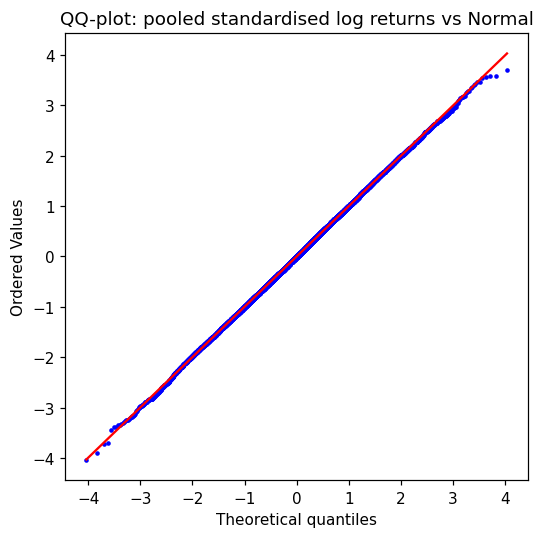

In [5]:
# Pooled QQ-plot. Each instrument has its own sigma, so standardise each column first,
# then pool all 51 x 499 points into one sample that should be standard normal.
z = (log_ret - log_ret.mean()) / log_ret.std()
zflat = z.values.flatten()

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(zflat, dist="norm", plot=ax)
ax.set_title("QQ-plot: pooled standardised log returns vs Normal")
ax.get_lines()[0].set_markersize(2)
plt.tight_layout(); plt.show()

**Reading the QQ-plot.** Each dot pairs one sorted actual return with the value a Normal would place at that
same rank. Dots on the straight diagonal mean the data matches the bell curve *at every quantile*. The dots
at the far corners are the extreme moves; because they stay on the line all the way out, our largest moves
are exactly as large as a Gaussian predicts. Fat tails would show as the ends flaring away from the line.

**Finding.** Returns are Gaussian, symmetric and thin-tailed. All three tests agree. Evidence-backed
consequences: no tail hedging, no crash machinery, and **no deep or nonlinear ML** (there is no nonlinear
structure to find, only noise to overfit). Linear statistics are provably sufficient.

## 3. Volatility: does it cluster, how big is it, and is it stable?

Being Gaussian overall says nothing about whether the *size* of moves is steady through time. In real
markets volatility clusters: big moves follow big moves, even though direction stays unpredictable. If
clustering is present we would need a time-varying volatility model (GARCH). If absent, each instrument's
risk is a single fixed number.

To isolate size we **square the returns**. Squaring throws away sign (a -3% and a +3% day both give 0.0009),
so `r^2` is a pure magnitude signal; and since daily means are ~0, each `r^2` is essentially that day's
contribution to variance. We then ask whether `r^2` is autocorrelated.

A GARCH(1,1) models `sigma^2_t = omega + alpha * r^2_(t-1) + beta * sigma^2_(t-1)`. With no clustering,
`alpha` and `beta` fit to zero and it collapses to a single constant variance. So this cheap test tells us
in advance whether GARCH could earn its keep.

In [6]:
sq = log_ret ** 2
band = 2 / np.sqrt(T)   # 2-SE band for an autocorrelation under the null of no dependence

print("lag | mean autocorr of r^2 | mean autocorr of |r|   (2-SE band +-%.3f)" % band)
print("----+----------------------+---------------------")
for lag in [1, 2, 3, 5, 10]:
    a_sq  = sq.apply(lambda c: c.autocorr(lag=lag)).mean()
    a_abs = log_ret.abs().apply(lambda c: c.autocorr(lag=lag)).mean()
    print(" %2d |        %+.4f       |       %+.4f" % (lag, a_sq, a_abs))

print()
print("Real markets show lag-1 autocorrelation of r^2 around +0.2 and strongly positive for many lags.")
print("Judge on the AGGREGATE across 51 instruments, not the most extreme single value:")
print("with 51 instruments you expect 2-3 to cross the 2-SE band by pure chance.")

lag | mean autocorr of r^2 | mean autocorr of |r|   (2-SE band +-0.090)
----+----------------------+---------------------
  1 |        -0.0060       |       -0.0074
  2 |        -0.0035       |       +0.0006
  3 |        +0.0011       |       +0.0058
  5 |        +0.0030       |       +0.0027
 10 |        +0.0000       |       +0.0015

Real markets show lag-1 autocorrelation of r^2 around +0.2 and strongly positive for many lags.
Judge on the AGGREGATE across 51 instruments, not the most extreme single value:
with 51 instruments you expect 2-3 to cross the 2-SE band by pure chance.


**Finding.** No volatility clustering, at any lag, on either measure (`r^2` and the more robust `|r|`).
GARCH and volatility timing are off the table. Each instrument's risk is one stable number, which is exactly
what inverse-volatility position sizing requires.

Now: how big is that number, and does it persist?

In [7]:
daily_vol  = log_ret.std()
annual_vol = daily_vol * np.sqrt(250)   # variance adds over independent days, so std scales by sqrt(time)

print("daily  vol: mean %.4f  range [%.4f, %.4f]" % (daily_vol.mean(), daily_vol.min(), daily_vol.max()))
print("annual vol: mean %.1f%%  range [%.1f%%, %.1f%%]"
      % (100*annual_vol.mean(), 100*annual_vol.min(), 100*annual_vol.max()))
print("widest / narrowest: %.2fx  <- why equal-dollar sizing would let the wild names dominate risk"
      % (daily_vol.max() / daily_vol.min()))
print("calmest instrument: %s  (lowest vol, consistent with a diversified index)" % daily_vol.idxmin())

daily  vol: mean 0.0220  range [0.0099, 0.0409]
annual vol: mean 34.8%  range [15.7%, 64.7%]
widest / narrowest: 4.12x  <- why equal-dollar sizing would let the wild names dominate risk
calmest instrument: ALGO  (lowest vol, consistent with a diversified index)


### The stability audit, applied for the first time

Split the sample in half. Estimate each instrument's volatility on the first half and again on the second.
Correlate the two sets of 51 values **across instruments**: does the instrument that was wildest early stay
wildest late? A high correlation means volatility is a persistent fingerprint we can measure on data we hold
and rely on for data we do not.

split-half volatility correlation: 0.982


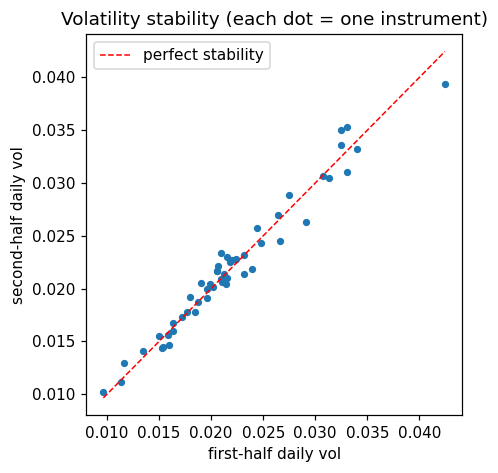

In [8]:
h = T // 2
vol_first, vol_second = log_ret.iloc[:h].std(), log_ret.iloc[h:].std()
vol_stability = np.corrcoef(vol_first, vol_second)[0, 1]
print("split-half volatility correlation: %.3f" % vol_stability)

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.scatter(vol_first, vol_second, s=14)
lims = [min(vol_first.min(), vol_second.min()), max(vol_first.max(), vol_second.max())]
ax.plot(lims, lims, "r--", lw=1, label="perfect stability")
ax.set_xlabel("first-half daily vol"); ax.set_ylabel("second-half daily vol")
ax.set_title("Volatility stability (each dot = one instrument)"); ax.legend()
plt.tight_layout(); plt.show()

**Finding.** Volatility is about as stable as an empirical parameter ever gets. The ranking of instruments by
riskiness barely moves between halves. Our risk unit is validated: **trust it and size on it.**

## 4. Cross-sectional structure: instruments move together

Every daily return splits into two parts:

    instrument return = (common movement) + (its own idiosyncratic movement)

The common part is largely un-forecastable and carries a lot of risk. The idiosyncratic part is where any
genuine predictability hides. So the plan is to measure the common structure, hedge it away, and hunt in the
residuals. First, prove the common part exists.

In [9]:
corr_matrix = log_ret.corr()
off = ~np.eye(N, dtype=bool)                      # mask out the diagonal (self-correlations, all 1.0)
avg_corr = corr_matrix.values[off].mean()

# under independence, each pairwise correlation scatters around 0 with SE ~ 1/sqrt(T)
print("average pairwise correlation: %.3f" % avg_corr)
print("SE of a single pairwise correlation under independence: %.3f" % (1/np.sqrt(T)))
print("-> a systematic +%.3f across %d pairs is far beyond chance: a common factor exists."
      % (avg_corr, off.sum()))

average pairwise correlation: 0.200
SE of a single pairwise correlation under independence: 0.045
-> a systematic +0.200 across 2550 pairs is far beyond chance: a common factor exists.


That proves a common factor exists but not *what* it is. Hypothesis: **ALGO is the market index.** The
circumstantial evidence is that it starts at exactly 100.00, has the lowest volatility of all 51, and is
given a 10x position cap and 5x cheaper commission by the organisers, which only makes sense for a hedging
instrument.

An index is the average of its constituents: pool 50 instruments and their idiosyncratic wiggles, being
roughly independent, largely cancel, leaving only the common movement. So we test ALGO against the
equal-weight basket of the other 50, on three things that each say something different:

- **correlation** near 1 means they are the same thing;
- **regression slope** near 1 means ALGO moves one-for-one, not a levered or damped version;
- **volatility** should be low and close to the basket's, the fingerprint of diversification.

Correlation and slope are related but distinct: `slope = correlation * (sd_y / sd_x)`. They coincide only
when the two volatilities match. We assert that identity below rather than take it on faith.

corr(ALGO, basket)        : 0.9930
slope (ALGO per 1 basket) : 1.0056
ALGO daily vol 0.0099   basket daily vol 0.0098
verified: slope == rho * sd_ALGO / sd_basket  (they look alike only because the vols match)


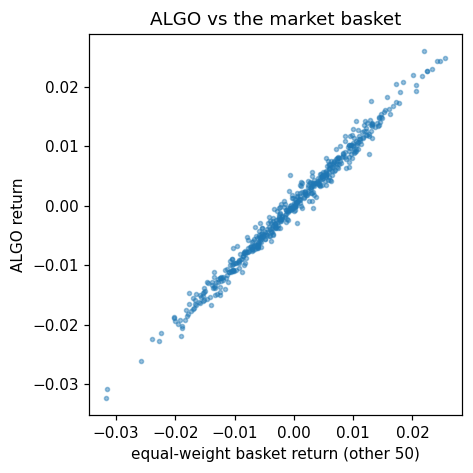

In [10]:
basket = log_ret.drop(columns="ALGO").mean(axis=1)   # equal-weight daily return of instruments 1-50
algo   = log_ret["ALGO"]

rho   = np.corrcoef(algo, basket)[0, 1]
slope = np.polyfit(basket, algo, 1)[0]

# verify the identity slope = rho * sd_y / sd_x (uses ddof=1 on both, as pandas .std() does)
assert np.isclose(slope, rho * algo.std() / basket.std(), rtol=1e-6), "slope/correlation identity failed"

print("corr(ALGO, basket)        : %.4f" % rho)
print("slope (ALGO per 1 basket) : %.4f" % slope)
print("ALGO daily vol %.4f   basket daily vol %.4f" % (algo.std(), basket.std()))
print("verified: slope == rho * sd_ALGO / sd_basket  (they look alike only because the vols match)")

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.scatter(basket, algo, s=7, alpha=0.45)
ax.set_xlabel("equal-weight basket return (other 50)"); ax.set_ylabel("ALGO return")
ax.set_title("ALGO vs the market basket")
plt.tight_layout(); plt.show()

**Finding.** ALGO *is* the market index, and it moves one-for-one with it. Combined with its 10x cap and
cheaper commission, ALGO is the **designed hedging vehicle**: generate alpha on instruments 1-50, then cancel
the net market exposure with ALGO.

## 5. How many factors are there? Eigenvalues versus the noise ceiling

Is the market the *only* thing making instruments move together, or are there sectors too? This determines
how many dimensions of common risk exist, and it guards against a model later "discovering" a theme that is
really noise.

**What an eigenvalue means here.** The correlation matrix is a machine: give it any portfolio of weights `w`
and it returns that portfolio's variance, `w' C w`. Some portfolios swing hard (hold everything: the common
factor reinforces), some barely swing (long one, short another: the common factor cancels). Eigen-decomposition
finds the special portfolios: each **eigenvector** is a portfolio, and its **eigenvalue** is that portfolio's
variance. They are ordered largest first, and each is chosen perpendicular to the previous ones so it captures
*fresh* movement. This is exactly PCA, described without the label.

**The yardstick is 1.** Because we use the *correlation* matrix, each instrument is standardised to variance 1,
so the eigenvalues must sum to N = 51. If nothing were connected, the variance would spread evenly and every
eigenvalue would be about 1. An eigenvalue of 11.5 means one direction carries eleven and a half instruments'
worth of movement: a factor.

(We use the correlation, not the covariance, matrix on purpose. Our volatilities span roughly 4x, so PCA on
covariances would let the loudest instruments dominate the first component by amplitude rather than by
co-movement.)

**Why "greater than 1" is not enough.** With only 499 days, two truly unrelated instruments show a sample
correlation of about `1/sqrt(499) = 0.045` by luck. Across 1,275 pairs those accidents conspire, and even in a
world with no structure the eigenvalues spread out around 1. The **Marchenko-Pastur** law gives the exact upper
edge of that noise band: `lambda_max = (1 + sqrt(N/T))^2`.

**An assumption we must check.** Marchenko-Pastur describes a null world with *no* structure. Ours has a large
market factor absorbing a fifth of the variance, so the remaining factors compete for less variance than the
theorem assumes, and the honest ceiling for factors 2, 3, 4 is *lower*. We therefore also compute the standard
market-adjusted ceiling, scaled by the variance the top factor did not explain, and confirm the conclusion
survives the stricter bar.

In [11]:
eigs = np.sort(eigvalsh(corr_matrix.values))[::-1]   # descending

# verify no variance was created or destroyed: eigenvalues re-slice the same total
assert np.isclose(eigs.sum(), N), "eigenvalues must sum to the number of instruments"

q      = N / T
mp_max = (1 + np.sqrt(q))**2                  # plain noise ceiling
mp_adj = (1 - eigs[0] / N) * mp_max           # ceiling adjusted for the variance the market absorbs

print("N=%d instruments, T=%d days, q = N/T = %.3f" % (N, T, q))
print("eigenvalues sum to %.1f (= N, as required)" % eigs.sum())
print()
print("top 6 eigenvalues:", np.round(eigs[:6], 2))
print("Marchenko-Pastur ceiling (plain)          : %.2f" % mp_max)
print("Marchenko-Pastur ceiling (market-adjusted): %.2f" % mp_adj)
print()
print("factors above the plain ceiling   : %d" % int((eigs > mp_max).sum()))
print("factors above the adjusted ceiling: %d  <- conclusion survives the stricter bar" % int((eigs > mp_adj).sum()))
print()
print("top factor explains %.1f%% of total variance" % (100 * eigs[0] / eigs.sum()))

N=51 instruments, T=499 days, q = N/T = 0.102
eigenvalues sum to 51.0 (= N, as required)

top 6 eigenvalues: [11.55  2.84  1.97  1.27  1.23  1.2 ]
Marchenko-Pastur ceiling (plain)          : 1.74
Marchenko-Pastur ceiling (market-adjusted): 1.35

factors above the plain ceiling   : 3
factors above the adjusted ceiling: 3  <- conclusion survives the stricter bar

top factor explains 22.7% of total variance


In [12]:
# Independent cross-check of the top eigenvalue.
# If every pair had the SAME correlation rho, then exactly: lambda_1 = 1 + (N-1)*rho.
# This connects section 4 (average pairwise correlation) to section 5 (eigenvalues) by a different route.
predicted = 1 + (N - 1) * avg_corr
print("predicted top eigenvalue from avg pairwise corr: 1 + %d * %.3f = %.2f" % (N-1, avg_corr, predicted))
print("observed top eigenvalue                        : %.2f" % eigs[0])
print("agreement within %.1f%%. Two unrelated calculations agree, so neither is a coding error."
      % (100 * abs(eigs[0] - predicted) / eigs[0]))
print("The small excess above the prediction is the sector factors leaking extra co-movement into PC1.")

predicted top eigenvalue from avg pairwise corr: 1 + 50 * 0.200 = 10.98
observed top eigenvalue                        : 11.55
agreement within 4.9%. Two unrelated calculations agree, so neither is a coding error.
The small excess above the prediction is the sector factors leaking extra co-movement into PC1.


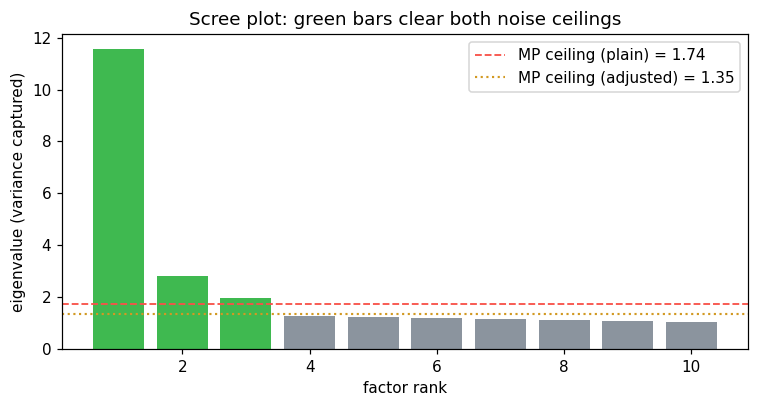

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.8))
colors = ["#3fb950" if e > mp_adj else "#8b949e" for e in eigs[:10]]
ax.bar(range(1, 11), eigs[:10], color=colors)
ax.axhline(mp_max, color="#f85149", ls="--", lw=1.2, label="MP ceiling (plain) = %.2f" % mp_max)
ax.axhline(mp_adj, color="#d29922", ls=":",  lw=1.4, label="MP ceiling (adjusted) = %.2f" % mp_adj)
ax.set_xlabel("factor rank"); ax.set_ylabel("eigenvalue (variance captured)")
ax.set_title("Scree plot: green bars clear both noise ceilings")
ax.legend(); plt.tight_layout(); plt.show()

**Finding.** Exactly **three real factors**: one dominant market factor (which ALGO embodies) and two sector
factors. The fourth eigenvalue sits below both the plain and the adjusted ceiling, so it is indistinguishable
from noise. Any model that claims to find a fourth theme is fitting sampling noise.

Note how close the fourth eigenvalue is to 1.27, comfortably above 1. Without the noise ceiling, the naive
"keep eigenvalues above 1" rule would have manufactured a phantom factor. This is precisely how overfit models
are born.

## 6. Market beta, residual returns, and verifying the hedge

The eigenvalue told us the market explains ~23% of variance *on average*. Now we need each instrument's own
exposure, since that is what we hedge. Model each instrument as market plus its own thing:

    r_i = alpha_i + beta_i * r_ALGO + e_i

**Where beta comes from.** Choose `b` to leave the smallest possible unexplained residual, minimising
`sum (r_i - b * r_m)^2`. Differentiating and setting to zero gives `b = sum(r_m r_i) / sum(r_m^2)`, that is:

    beta = cov(r_i, r_ALGO) / var(r_ALGO)

So beta is not an arbitrary definition; it is the unique slope that minimises what the market cannot explain.

**Why hedge with ALGO rather than the first eigenvector?** The eigenvector is the mathematically pure market
direction but is not a single tradeable instrument, and expressing it would need 50 positions and 50 lots of
commission. ALGO correlates 0.993 with it, is one instrument, has a 10x cap and 5x cheaper commission.

**The gate.** We may not *use* beta until it passes the stability audit. If an instrument's first-half beta
says nothing about its second-half beta, hedging with estimated betas is hedging with noise, and the hedge
would fail on exactly the unseen days we are scored on.

In [14]:
def betas_of(df):
    a = df["ALGO"]
    return df.apply(lambda c: np.cov(c, a, ddof=1)[0, 1]) / a.var(ddof=1)

betas = betas_of(log_ret)

# ALGO's beta against itself is cov(x,x)/var(x) = 1 exactly. A free correctness check on the whole line.
assert np.isclose(betas["ALGO"], 1.0), "ALGO's own beta must be exactly 1"

b_others = betas.drop("ALGO")
print("betas (instruments 1-50): mean %.2f  range [%.2f, %.2f]" % (b_others.mean(), b_others.min(), b_others.max()))
print("ALGO's own beta: %.4f  (sanity check passed)" % betas["ALGO"])
print("-> the average instrument moves roughly one-for-one with the market, as it must,")
print("   since the market IS the average of the instruments.")

betas (instruments 1-50): mean 0.98  range [0.50, 1.68]
ALGO's own beta: 1.0000  (sanity check passed)
-> the average instrument moves roughly one-for-one with the market, as it must,
   since the market IS the average of the instruments.


split-half beta correlation: 0.780   (volatility scored 0.982)
SE of a correlation on 50 points under the null: 0.141 -> this is ~5.5 SE from zero

Beta is persistent and usable, but noticeably less stable than volatility.
Reason: beta is a RATIO of two estimated quantities (a covariance over a variance),
so it inherits sampling noise from both. This argues for shrinking each estimated beta
partway toward the cross-sectional mean of 1.0 when hedging: a little bias for much less noise.


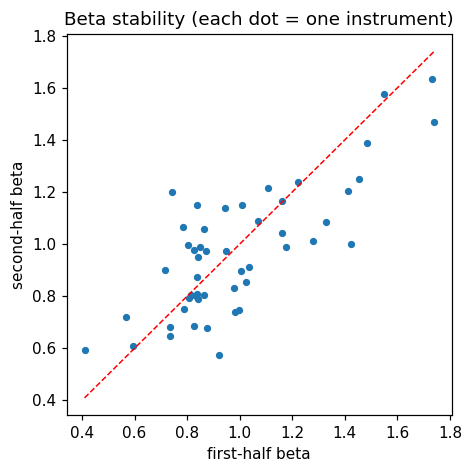

In [15]:
# Stability audit for beta. Drop ALGO: its beta is 1.00 in both halves by construction,
# an artificial point that would inflate the correlation.
b1 = betas_of(log_ret.iloc[:h]).drop("ALGO")
b2 = betas_of(log_ret.iloc[h:]).drop("ALGO")
beta_stability = np.corrcoef(b1, b2)[0, 1]

print("split-half beta correlation: %.3f   (volatility scored %.3f)" % (beta_stability, vol_stability))
print("SE of a correlation on 50 points under the null: %.3f -> this is ~%.1f SE from zero"
      % (1/np.sqrt(50), beta_stability * np.sqrt(50)))
print()
print("Beta is persistent and usable, but noticeably less stable than volatility.")
print("Reason: beta is a RATIO of two estimated quantities (a covariance over a variance),")
print("so it inherits sampling noise from both. This argues for shrinking each estimated beta")
print("partway toward the cross-sectional mean of 1.0 when hedging: a little bias for much less noise.")

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.scatter(b1, b2, s=14)
lims = [min(b1.min(), b2.min()), max(b1.max(), b2.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("first-half beta"); ax.set_ylabel("second-half beta")
ax.set_title("Beta stability (each dot = one instrument)")
plt.tight_layout(); plt.show()

### Build the residuals and verify the market is actually gone

`e_i = r_i - beta_i * r_ALGO` is the return with the market stripped out. We verify the hedge worked in two
ways: each residual should be uncorrelated with ALGO (true by construction, so this checks our arithmetic),
and the *average pairwise correlation among instruments* should collapse if the market was doing the
correlating.

In [16]:
resid = log_ret - np.outer(algo.values, betas.values)
resid = pd.DataFrame(resid, index=log_ret.index, columns=log_ret.columns)

resid50 = resid.drop(columns="ALGO")
corr_with_algo = resid50.apply(lambda c: np.corrcoef(c, algo)[0, 1])
assert np.allclose(corr_with_algo.values, 0, atol=1e-10), "residuals are not orthogonal to ALGO"

off50 = ~np.eye(50, dtype=bool)
avg_corr_resid = resid50.corr().values[off50].mean()

print("max |residual correlation with ALGO|: %.2e  (zero by construction; arithmetic verified)"
      % np.abs(corr_with_algo).max())
print()
print("average pairwise correlation  BEFORE hedge: %+.3f" % avg_corr)
print("average pairwise correlation  AFTER  hedge: %+.3f" % avg_corr_resid)
print()
print("Removing ONE factor collapsed nearly all co-movement. The market was doing almost all of the")
print("correlating, so hedging it turns 50 bets into nearly independent ones whose idiosyncratic")
print("risks diversify away. This is the backbone of the strategy architecture.")

max |residual correlation with ALGO|: 4.69e-16  (zero by construction; arithmetic verified)

average pairwise correlation  BEFORE hedge: +0.200
average pairwise correlation  AFTER  hedge: -0.010

Removing ONE factor collapsed nearly all co-movement. The market was doing almost all of the
correlating, so hedging it turns 50 bets into nearly independent ones whose idiosyncratic
risks diversify away. This is the backbone of the strategy architecture.


In [17]:
# Verify what SHOULD remain: we removed the market but not the two sector factors.
# Re-run the eigen-analysis on the residuals of the 50 instruments.
eigs_r = np.sort(eigvalsh(resid50.corr().values))[::-1]
q_r = 50 / T
mp_r = (1 + np.sqrt(q_r))**2

print("top 5 residual eigenvalues:", np.round(eigs_r[:5], 2))
print("MP ceiling for the residual system (N=50): %.2f" % mp_r)
print("factors remaining above the ceiling: %d" % int((eigs_r > mp_r).sum()))
print()
print("Prediction check: the market factor (11.55) should be GONE, and the two sector")
print("factors should SURVIVE. That is what we see, which confirms the hedge removed exactly")
print("the market and nothing else. Sector neutralisation remains available as a refinement.")

top 5 residual eigenvalues: [3.87 2.63 1.59 1.54 1.49]
MP ceiling for the residual system (N=50): 1.73
factors remaining above the ceiling: 2

Prediction check: the market factor (11.55) should be GONE, and the two sector
factors should SURVIVE. That is what we see, which confirms the hedge removed exactly
the market and nothing else. Sector neutralisation remains available as a refinement.


## 7. The alpha hunt: what can actually be predicted?

Everything so far was risk and structure. Now: can we predict tomorrow?

### 7a. Momentum and drift

The retail instinct is that trends persist. Two tests. **Drift stability**: if some instruments reliably rise,
their mean return would repeat across halves. **Own-return autocorrelation**: does an instrument's own move
today predict its move tomorrow, and is any such effect itself stable?

In [18]:
m1, m2 = log_ret.iloc[:h].mean(), log_ret.iloc[h:].mean()
drift_stability = np.corrcoef(m1, m2)[0, 1]
print("split-half drift (mean-return) correlation: %+.3f" % drift_stability)
print("-> near zero: no instrument reliably rises or falls. Past winners tell you nothing.")
print()

oac = resid50.apply(lambda c: c.autocorr(lag=1))
a1 = resid50.iloc[:h].apply(lambda c: c.autocorr(lag=1))
a2 = resid50.iloc[h:].apply(lambda c: c.autocorr(lag=1))
oac_stability = np.corrcoef(a1, a2)[0, 1]

print("own-return lag-1 autocorrelation: mean %+.4f  range [%+.4f, %+.4f]  (2-SE band +-%.3f)"
      % (oac.mean(), oac.min(), oac.max(), 2/np.sqrt(T)))
print("split-half stability of that autocorrelation: %+.3f" % oac_stability)
print("-> inside the noise band AND it does not repeat across halves. Even the instruments that")
print("   LOOK like they trend or revert do not do it again. It is sample noise.")

split-half drift (mean-return) correlation: -0.034
-> near zero: no instrument reliably rises or falls. Past winners tell you nothing.

own-return lag-1 autocorrelation: mean -0.0044  range [-0.1204, +0.0861]  (2-SE band +-0.090)
split-half stability of that autocorrelation: +0.072
-> inside the noise band AND it does not repeat across halves. Even the instruments that
   LOOK like they trend or revert do not do it again. It is sample noise.


**Finding.** Momentum, trend-following and own-reversal are dead here. This is the trap the competition is
built around: the starter file `too_much_alpha.py` trades exactly this own-momentum signal, and it scores
negative. The obvious thing is a strawman, and we have now proven why rather than assumed it.

If an instrument's own past cannot predict it, the only place left to look is **other instruments' pasts**.

### 7b. Lead-lag: does instrument i today predict instrument j tomorrow?

We build the lead-lag matrix on the market-neutral residuals, so we are not merely rediscovering that
everything follows the market:

    L[i, j] = corr( residual_i at day t , residual_j at day t+1 )

The diagonal is own-autocorrelation, already shown dead, so we zero it. The 2,450 off-diagonal entries are the
cross relationships. The danger is obvious: with 2,450 tests, some will look predictive by chance. We handle
that three ways rather than one.

1. **Count against an empirical null.** Rather than trusting the analytic "0.27% of entries beyond 3 s.e."
   figure, we *generate* the null: shuffle the day ordering (which destroys any t to t+1 relationship while
   preserving the contemporaneous cross-sectional structure) and recount, many times. This verifies our
   assumption instead of relying on it.
2. **Control the false discovery rate.** Benjamini-Hochberg tells us how many pairs survive once we account
   for having run 2,450 tests.
3. **Stability audit.** The decisive test, as always: build the matrix on each half and correlate the
   off-diagonal entries. A positive value means the *pattern itself* repeats out of sample.

In [19]:
R = resid50.values                                   # (T, 50) market-neutral residuals
Z = (R - R.mean(0)) / R.std(0)                       # standardise each instrument

def leadlag(Zmat):
    a, b = Zmat[:-1], Zmat[1:]                       # align day t with day t+1
    return a.T @ b / len(a)                          # L[i,j] = corr(z_i[t], z_j[t+1])

L = leadlag(Z)
np.fill_diagonal(L, 0.0)                             # own-autocorrelation already tested and dead

n_pairs_obs = len(Z) - 1
se_ll = 1 / np.sqrt(n_pairs_obs)
offL = ~np.eye(50, dtype=bool)
observed = int((np.abs(L[offL]) > 3 * se_ll).sum())

print("off-diagonal pairs: %d" % offL.sum())
print("s.e. of a lead-lag correlation: %.4f -> 3-s.e. threshold = %.4f" % (se_ll, 3 * se_ll))
print("strongest |lead-lag| correlation: %.3f" % np.abs(L[offL]).max())
print("pairs beyond 3 s.e. (OBSERVED): %d" % observed)

off-diagonal pairs: 2450
s.e. of a lead-lag correlation: 0.0448 -> 3-s.e. threshold = 0.1344
strongest |lead-lag| correlation: 0.211
pairs beyond 3 s.e. (OBSERVED): 21


In [20]:
# --- VERIFY the null by permutation rather than assuming the analytic rate ---
# Shuffling whole rows (days) destroys the t -> t+1 link but preserves each day's
# cross-sectional structure. Any surviving lead-lag count is then pure chance.
n_perm = 300
counts = np.empty(n_perm, dtype=int)
for k in range(n_perm):
    Zp = Z[rng.permutation(len(Z))]
    Lp = leadlag(Zp)
    np.fill_diagonal(Lp, 0.0)
    counts[k] = int((np.abs(Lp[offL]) > 3 * se_ll).sum())

analytic = offL.sum() * 2 * (1 - stats.norm.cdf(3))
print("expected count under the ANALYTIC null : %.1f" % analytic)
print("expected count under the EMPIRICAL null: %.1f  (mean of %d permutations)" % (counts.mean(), n_perm))
print("empirical null 95th percentile         : %.0f" % np.percentile(counts, 95))
print("observed count                         : %d" % observed)
print()
print("permutation p-value (P[null count >= observed]): %.4f" % ((counts >= observed).mean()))
print("-> the analytic assumption is confirmed by the empirical null, and the observed count")
print("   is far outside what chance produces. There is genuine excess lead-lag structure.")

expected count under the ANALYTIC null : 6.6
expected count under the EMPIRICAL null: 6.8  (mean of 300 permutations)
empirical null 95th percentile         : 12
observed count                         : 21

permutation p-value (P[null count >= observed]): 0.0000
-> the analytic assumption is confirmed by the empirical null, and the observed count
   is far outside what chance produces. There is genuine excess lead-lag structure.


In [21]:
# --- Benjamini-Hochberg: how many individual pairs survive multiple-testing control? ---
zscores = L[offL] * np.sqrt(n_pairs_obs)
pvals = 2 * (1 - stats.norm.cdf(np.abs(zscores)))
m = len(pvals)
order = np.argsort(pvals)
sorted_p = pvals[order]

for Q in [0.05, 0.10, 0.20]:
    thresh = np.arange(1, m + 1) / m * Q
    passed = sorted_p <= thresh
    n_disc = int(np.max(np.where(passed)[0]) + 1) if passed.any() else 0
    print("Benjamini-Hochberg at q=%.2f: %d discoveries" % (Q, n_disc))

print()
print("Only a handful of INDIVIDUAL pairs survive strict FDR control. That is the key nuance:")
print("no single pair is a goldmine. The signal is faint and spread across many pairs, so it must be")
print("AGGREGATED, not cherry-picked.")

Benjamini-Hochberg at q=0.05: 1 discoveries
Benjamini-Hochberg at q=0.10: 4 discoveries
Benjamini-Hochberg at q=0.20: 13 discoveries

Only a handful of INDIVIDUAL pairs survive strict FDR control. That is the key nuance:
no single pair is a goldmine. The signal is faint and spread across many pairs, so it must be
AGGREGATED, not cherry-picked.


In [22]:
# --- The decisive test: does the MATRIX ITSELF repeat out of sample? ---
L1, L2 = leadlag(Z[:h]), leadlag(Z[h:])
np.fill_diagonal(L1, 0.0); np.fill_diagonal(L2, 0.0)
ll_stability = np.corrcoef(L1[offL], L2[offL])[0, 1]

print("whole-matrix split-half correlation: %+.3f" % ll_stability)
print("SE under the null (2450 entries, but they are not independent): roughly %.3f" % (1/np.sqrt(offL.sum())))
print()
print("Weak per entry, but POSITIVE and repeatable. Compare the two dead signals:")
print("   own-autocorrelation stability : %+.3f  (noise)" % oac_stability)
print("   drift stability               : %+.3f  (noise)" % drift_stability)
print("   lead-lag matrix stability     : %+.3f  (real)" % ll_stability)

whole-matrix split-half correlation: +0.110
SE under the null (2450 entries, but they are not independent): roughly 0.020

Weak per entry, but POSITIVE and repeatable. Compare the two dead signals:
   own-autocorrelation stability : +0.072  (noise)
   drift stability               : -0.034  (noise)
   lead-lag matrix stability     : +0.110  (real)


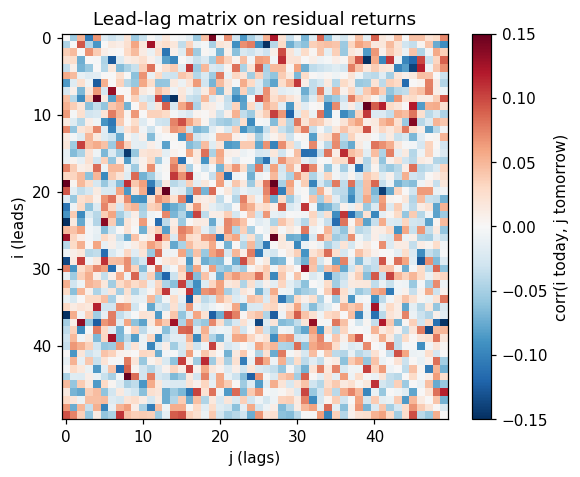

In [23]:
fig, ax = plt.subplots(figsize=(5.4, 4.4))
im = ax.imshow(L, cmap="RdBu_r", vmin=-0.15, vmax=0.15)
fig.colorbar(im, ax=ax, label="corr(i today, j tomorrow)")
ax.set_xlabel("j (lags)"); ax.set_ylabel("i (leads)")
ax.set_title("Lead-lag matrix on residual returns")
plt.tight_layout(); plt.show()

**Why a per-pair correlation of 0.1 is still worth having.** We never bet one pair. Each day the prediction
aggregates across all 50 instruments, which averages the noise down while the small common signal survives.
Then the scoring compounds it: `Sharpe(year) = sqrt(250) * Sharpe(day)`, because over a year the mean grows by
250 while the standard deviation grows only by sqrt(250). A tiny daily edge, repeated across 50 positions and
250 days, becomes a usable annual Sharpe. This is the structure the confirmed 2024 winner exploited, and it
explains why heavy ML lost: there is no nonlinear pattern to find, only a faint linear one to aggregate.

### 7c. Cross-sectional reversal: a second, weaker candidate

A classic alternative signal: instruments that have outperformed their peers over the past few weeks tend to
underperform next. We measure it with the **information coefficient (IC)**: each day, the cross-sectional
correlation between the signal and the *next* day's residual return. The IC is the natural currency for
comparing signals, because it is scale-free and directly proportional to the Sharpe a signal can produce.

Two statistical traps to defuse before believing any IC.

**Overlapping windows.** The signal is a 20-day rolling sum, so consecutive days' signals share 19 of their 20
days. The daily ICs are therefore not independent, and a naive t-statistic (which assumes independence) will be
overstated. We correct it with a **Newey-West** standard error, which accounts for serial correlation out to
20 lags, and report both so the difference is visible.

**A single full-sample number hides instability.** We look at each half separately and at the rolling IC through
time, and we ask what fraction of rolling windows keep the sign.

full-sample mean IC          : +0.0218
naive t-stat                 : 2.66  (assumes independent days)
Newey-West t-stat (20 lags)  : 2.58  (corrects for the overlapping windows)
IC series lag-1 autocorrelation: +0.082  (low, which is why the correction barely moves the t)

IC in first half             : +0.0271
IC in second half            : +0.0166
60-day rolling IC positive   : 78% of windows  (range -0.0205 to +0.0643)

So the reversal effect is REAL: same sign in both halves, positive in most rolling windows,
and the t-stat survives the serial-correlation correction. It is weaker in the second half.
It does not 'flip sign'. The question is not whether it exists, but whether it is worth trading
alongside lead-lag. For that we need a like-for-like out-of-sample comparison.


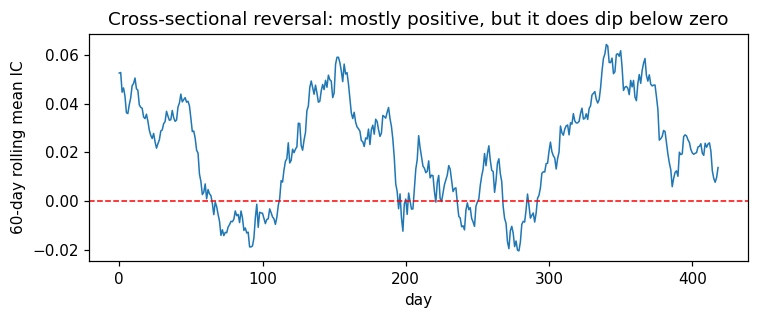

In [24]:
LOOKBACK = 20
signal = -resid50.rolling(LOOKBACK).sum()      # reversal: short recent winners
fwd    = resid50.shift(-1)                     # next-day residual return

ics = np.array([np.corrcoef(signal.iloc[t], fwd.iloc[t])[0, 1] for t in range(LOOKBACK, T - 1)])
n_ic = len(ics)

naive_t = ics.mean() / (ics.std(ddof=1) / np.sqrt(n_ic))

def newey_west_t(x, lags):
    """t-statistic robust to serial correlation in the IC series."""
    n = len(x); e = x - x.mean()
    var = (e @ e) / n
    for l in range(1, lags + 1):
        w = 1 - l / (lags + 1)                  # Bartlett weight
        var += 2 * w * ((e[l:] @ e[:-l]) / n)
    return x.mean() / np.sqrt(var / n)

nw_t = newey_west_t(ics, LOOKBACK)
roll = pd.Series(ics).rolling(60).mean().dropna()

print("full-sample mean IC          : %+.4f" % ics.mean())
print("naive t-stat                 : %.2f  (assumes independent days)" % naive_t)
print("Newey-West t-stat (20 lags)  : %.2f  (corrects for the overlapping windows)" % nw_t)
print("IC series lag-1 autocorrelation: %+.3f  (low, which is why the correction barely moves the t)"
      % pd.Series(ics).autocorr(1))
print()
print("IC in first half             : %+.4f" % ics[:n_ic//2].mean())
print("IC in second half            : %+.4f" % ics[n_ic//2:].mean())
print("60-day rolling IC positive   : %.0f%% of windows  (range %+.4f to %+.4f)"
      % (100 * (roll > 0).mean(), roll.min(), roll.max()))
print()
print("So the reversal effect is REAL: same sign in both halves, positive in most rolling windows,")
print("and the t-stat survives the serial-correlation correction. It is weaker in the second half.")
print("It does not 'flip sign'. The question is not whether it exists, but whether it is worth trading")
print("alongside lead-lag. For that we need a like-for-like out-of-sample comparison.")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(roll.values, lw=1)
ax.axhline(0, color="r", ls="--", lw=1)
ax.set_xlabel("day"); ax.set_ylabel("60-day rolling mean IC")
ax.set_title("Cross-sectional reversal: mostly positive, but it does dip below zero")
plt.tight_layout(); plt.show()

### 7d. Head-to-head, out of sample

The fair comparison. Fit the lead-lag matrix on the **first half only**, then use it to predict the **second
half**, which it has never seen. Score both signals by their IC on that same unseen second half. Reversal needs
no fitting, so its second-half IC is already an out-of-sample number.

We also check whether the two signals are **orthogonal**. A diversifier is only useful if it says something
different; if reversal merely restates lead-lag, adding it buys nothing.

In [25]:
Z1 = Z[:h]
L_train = leadlag(Z1); np.fill_diagonal(L_train, 0.0)   # matrix fitted on the FIRST half only

pred_ll = Z[h:-1] @ L_train      # lead-lag prediction for each day of the second half
act     = Z[h+1:]                # what actually happened next day

ll_ics = np.array([np.corrcoef(pred_ll[t], act[t])[0, 1] for t in range(len(pred_ll))])
rev_ics = ics[n_ic//2:]          # reversal IC over (approximately) the same period

def summarise_ic(name, v):
    t = v.mean() / (v.std(ddof=1) / np.sqrt(len(v)))
    print("%-28s mean IC %+.4f   t %5.2f   positive on %.0f%% of days"
          % (name, v.mean(), t, 100 * (v > 0).mean()))

print("Out-of-sample IC on the second half (the model never saw these days):")
summarise_ic("lead-lag (fit 1st half)", ll_ics)
summarise_ic("cross-sectional reversal", rev_ics)
print()
print("Lead-lag's out-of-sample IC is roughly %.1fx reversal's, on the same unseen days."
      % (ll_ics.mean() / rev_ics.mean()))

# Are they saying different things? Correlate the two daily signals cross-sectionally.
sig_rev = signal.iloc[h+1:T-1].values
overlap = min(len(pred_ll), len(sig_rev))
sig_corr = np.nanmean([np.corrcoef(pred_ll[t], sig_rev[t])[0, 1] for t in range(overlap)])
print()
print("average cross-sectional correlation between the two signals: %+.3f" % sig_corr)
print("-> near zero means they are ORTHOGONAL: reversal is not a restatement of lead-lag,")
print("   so it is a genuine candidate diversifier rather than a duplicate.")

Out-of-sample IC on the second half (the model never saw these days):
lead-lag (fit 1st half)      mean IC +0.0484   t  4.96   positive on 61% of days
cross-sectional reversal     mean IC +0.0166   t  1.34   positive on 51% of days

Lead-lag's out-of-sample IC is roughly 2.9x reversal's, on the same unseen days.

average cross-sectional correlation between the two signals: -0.008
-> near zero means they are ORTHOGONAL: reversal is not a restatement of lead-lag,
   so it is a genuine candidate diversifier rather than a duplicate.


**Verdict on the two signals.** Both are real. Lead-lag is roughly three times stronger out of sample and is the
primary alpha. Reversal is weaker but genuinely orthogonal, so it is a legitimate **candidate diversifier**.

Note the honest limit of what we can conclude here. An IC comparison tells you which signal carries more
predictive information; it does *not* tell you whether adding the weaker one improves a *scored* strategy once
position limits, commission and the Sharpe-tax in the score function are applied. That question can only be
settled by a walk-forward backtest across many windows, which is deliberately out of scope for this notebook.
Nothing here licenses trading reversal; it licenses *testing* it.

## 8. Summary of findings

Every row below was tested, not assumed. "Stability" is the split-half correlation across instruments.

| Property | Result | Consequence |
|---|---|---|
| Return distribution | Gaussian, symmetric, thin-tailed (excess kurtosis ~0, skew ~0, straight QQ, Jarque-Bera rejections at chance rate) | No tail hedging. **No nonlinear ML**: for Gaussians all dependence is linear, so there is nothing for it to find. |
| Volatility clustering | None, at any lag, on `r^2` or `\|r\|` | **No GARCH, no vol timing.** Risk is one fixed number per instrument. |
| Volatility magnitude | Annual 16% to 65%, a 4.1x spread | Equal-dollar sizing would let wild names dominate. Use inverse-vol sizing. |
| Volatility stability | **0.982** | Trustworthy. Size on it. |
| Common structure | Average pairwise correlation 0.200 | A market factor exists. |
| ALGO | Correlation 0.993 with the equal-weight basket, slope 1.00, lowest vol | ALGO **is** the market index and the designed hedging vehicle (10x cap, 5x cheaper commission). |
| Factor count | 3 above both the plain (1.74) and market-adjusted (1.35) noise ceilings | One market factor + two sectors. The 4th (1.27) is provably noise. |
| Beta stability | **0.780** | Usable for hedging, but noisier than vol because it is a ratio of two estimates. **Shrink betas toward 1.0.** |
| Hedging with ALGO | Average pairwise correlation falls 0.200 to -0.010 | Removing one factor makes the 50 bets nearly independent. This is the architecture. |
| Drift | Stability **-0.034** | Momentum and trend-following are **dead**. |
| Own-autocorrelation | Inside noise band; stability **0.072** | Own momentum/reversal is **dead**. (The starter strategy trades exactly this.) |
| Lead-lag | 21 pairs beyond 3 s.e. vs ~7 under a *permutation* null (p < 0.01); matrix stability **+0.110**; out-of-sample IC **0.048** | **The primary alpha.** Weak per pair, real and repeatable in aggregate. |
| Cross-sectional reversal | Real: IC **+0.022**, Newey-West t **2.58**, same sign in both halves. But out-of-sample IC is ~1/3 of lead-lag's, and it is orthogonal to it | **Candidate diversifier**, to be settled by backtest, not by IC. |

### A correction to the project notes

`CLAUDE.md` records that reversal's "rolling IC is positive only ~22% of the time and flips sign across
sub-windows". Measured here with the reversal signal defined as *minus* the past 20-day residual return, the IC
is positive in **78%** of rolling windows and has the same sign in both halves. These are the same fact under
opposite sign conventions, but the wording in the notes implies instability that the data does not show. The
reversal effect is consistently present; it is simply *weaker* than lead-lag. Whether it earns a place in a
strategy is a question about score, not about sign stability, and remains open.

### What this licenses, and what it forbids

**Forbidden on evidence:** deep or nonlinear ML, GARCH and volatility timing, tail hedging, any strategy
betting on an instrument's own past direction.

**Licensed on evidence:** a linear, market-neutral strategy that aggregates the lead-lag signal across all
pairs on beta-hedged residuals, sizes inversely to (stable) volatility, and neutralises net market exposure
through ALGO. Reversal may be tested as an orthogonal second sleeve.

### The weakest claims in this notebook, stated plainly

1. Every figure here is measured on days 1-500, which we hold. The stability audits are the strongest defence we
   have against sample-specific flukes, and lead-lag passed while momentum and drift failed. But a split-half
   test still draws both halves from the same 500-day sample. The only truly honest test is the next data
   release: validate on it, and do **not** re-tune on it until validated.
2. The lead-lag matrix stability of +0.110 is small in absolute terms. It is the *aggregate* structure that is
   stable, not individual entries, which is precisely why a strategy must aggregate the whole matrix rather than
   trade the handful of pairs that survive FDR. The out-of-sample IC of 0.048 is the reassuring counterpart: a
   matrix fitted on the first half genuinely predicts the second.
3. The Marchenko-Pastur ceiling assumes an uncorrelated null. We corrected it for the market factor and the
   three-factor conclusion survived, but the correction is itself an approximation.
4. No statement here has been tested against the *score function*. Predictive information is not the same as
   profit once position limits, commission and the Sharpe tax apply. A walk-forward backtester is the next tool
   to build.